# <font color="royalblue"><b> DETEKCIJA TEMA U *Youtube* KOMENTARIMA FANOVA EMISIE “GOING SEVENTEEN“ PRIMENOM BERTopic MODELA </b> </font>

## <font color="dodgerblue"><b> Imports </b> </font>

In [1]:
import spacy
import thinc

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.graph_objects as go

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF, LatentDirichletAllocation

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

from gensim import corpora
from gensim.models import CoherenceModel, Word2Vec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

sns.set_theme(palette="pastel")

## <font color="dodgerblue"><b> Učitavanje i osnovna statistika </b> </font>

Podaci su prikupljeni sa YouTube kanala Going Seventeen putem YouTube Data API v3.
Skup podataka sadrži komentare iz dve kategorije:
- **recent** – komentari sa najnovijih videa i
- **popular** – komentari sa najgledanijih videa.

In [3]:
df = pd.read_csv('going_seventeen_comments.csv', encoding='utf-8-sig')
print(f'Ukupno redova: {len(df)}')
print(f'Kolone: {list(df.columns)}')
df.head()

Ukupno redova: 74552
Kolone: ['video_id', 'text', 'likes', 'date', 'video_title', 'type']


,video_id,text,likes,date,video_title,type
0,TJWUc875kpU,I think the production team could also create ...,0,2026-04-04T10:58:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
1,TJWUc875kpU,"Honestly, i agree with Dino. I think they keep...",0,2026-04-04T06:20:04Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
2,TJWUc875kpU,I’m glad Minghao brought up that he and Jun fe...,0,2026-04-04T00:35:36Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
3,TJWUc875kpU,"I understand the discussion, but I think I wou...",0,2026-04-03T15:37:59Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent
4,TJWUc875kpU,Unpopular opinion: please bring the resolution...,2,2026-04-02T22:35:00Z,[GOING SEVENTEEN SPECIAL] 2026 고잉 긴급 회의 (Agend...,recent


In [4]:
print('=== OSNOVNA STATISTIKA ===')
print(f'Ukupno komentara:  {len(df):,}')
print(f'\nPo tipu videa:')
print(df['type'].value_counts().to_string())
print(f'\nPo videu:')
print(df['video_title'].value_counts().to_string())
print(f'\nLikes – prosek: {df["likes"].mean():.2f},  max: {df["likes"].max()}')

=== OSNOVNA STATISTIKA ===
Ukupno komentara:  74,552

Po tipu videa:
type
popular    64652
recent      9900

Po videu:
video_title
[GOING SEVENTEEN 2020] EP.27 술래잡기 #1 (The Tag #1)                                      11325
[GOING SEVENTEEN 2020] EP.44 TTT #1 (Hyperrealism Ver.)                                 8523
[GOING SEVENTEEN 2020] EP.25 디에잇과 12인의 그림자 #1 (THE 8 and the 12 Shadows #1)             7405
[GOING SEVENTEEN 2020] EP.45 TTT #2 (Hyperrealism Ver.)                                 6679
[GOING SEVENTEEN 2020] EP.23 드립 : 세븐틴 갓 탤런트 #1 (Ad-lib : Seventeen's got Talent #1)     6536
[GOING SEVENTEEN 2020] EP.40 돈't Lie Ⅱ #1 (Don't Lie Ⅱ #1)                              6126
[GOING SEVENTEEN] EP.32 순응특집 단짝 #2 (Best Friends #2)                                    5167
[GOING SEVENTEEN] EP.31 순응특집 단짝 #1 (Best Friends #1)                                    4676
[GOING SEVENTEEN] EP.18 TTT에 빠지다 #1 (Dive into TTT #1)                                  4516
[GOING SEVENTEEN] EP.24 부족오락관 #2

## <font color="dodgerblue"><b> Analiza teksta </b> </font>

Pre primene ikakvih NLP transformacija, analiziramo sirove komentare:
- **Dužinu komentara** 
- **Vokabular** 
- **Leksicku raznovrsnost (TTR)**

### <font color="steelblue"><b> Dužina komentara </b> </font>

=== STATISTIKA DUŽINE KOMENTARA ===
       char_count  word_count  sent_count
count    74552.00    74552.00    74552.00
mean       107.39       16.57        2.41
std        146.59       21.34        3.09
min          2.00        1.00        1.00
25%         46.00        7.00        1.00
50%         79.00       12.00        2.00
75%        123.00       18.00        3.00
max       8827.00      995.00      201.00


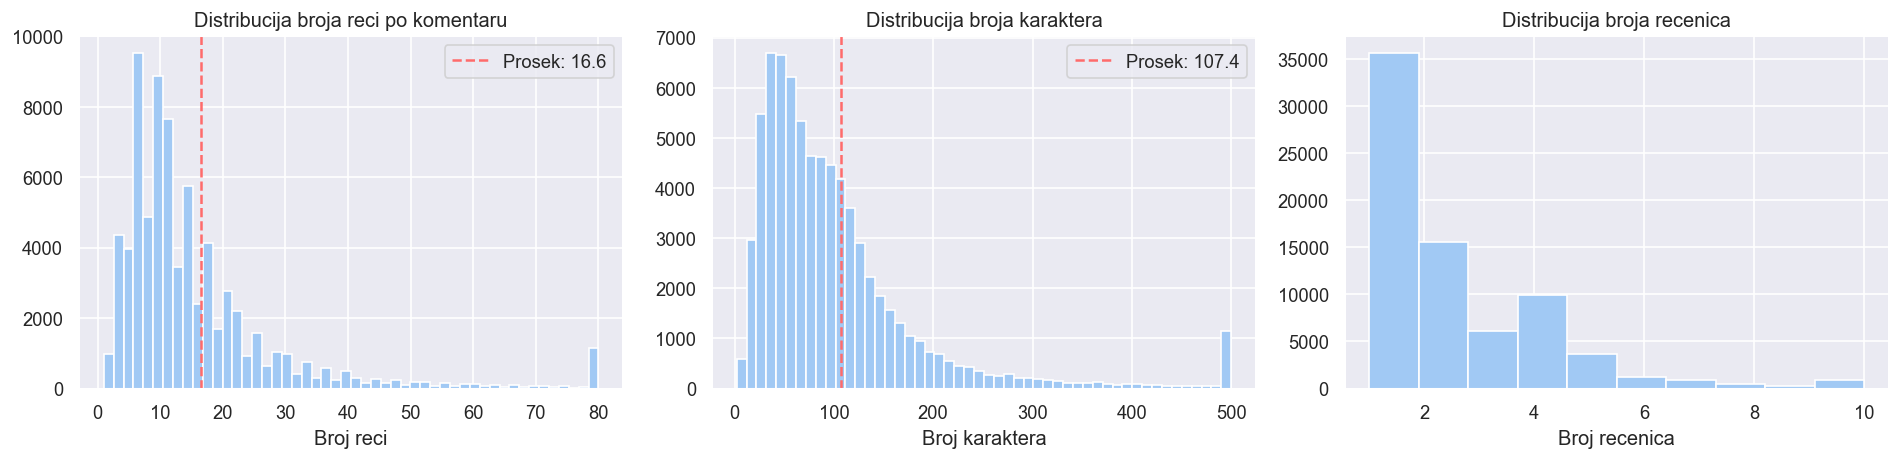

In [5]:
df['char_count'] = df['text'].apply(lambda x: len(str(x)))
df['word_count']  = df['text'].apply(lambda x: len(str(x).split()))
df['sent_count']  = df['text'].apply(
    lambda x: max(1, len(re.split(r'[.!?]+', str(x).strip()))))

desc = df[['char_count', 'word_count', 'sent_count']].describe().round(2)
print('=== STATISTIKA DUŽINE KOMENTARA ===')
print(desc)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['word_count'].clip(upper=80), bins=50, edgecolor='white')
axes[0].axvline(df['word_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["word_count"].mean():.1f}')
axes[0].set_title('Distribucija broja reci po komentaru')
axes[0].set_xlabel('Broj reci')
axes[0].legend()

axes[1].hist(df['char_count'].clip(upper=500), bins=50, edgecolor='white')
axes[1].axvline(df['char_count'].mean(), color='#FF6B6B', linestyle='--',
                label=f'Prosek: {df["char_count"].mean():.1f}')
axes[1].set_title('Distribucija broja karaktera')
axes[1].set_xlabel('Broj karaktera')
axes[1].legend()

axes[2].hist(df['sent_count'].clip(upper=10), bins=10, edgecolor='white')
axes[2].set_title('Distribucija broja recenica')
axes[2].set_xlabel('Broj recenica')

plt.tight_layout()
plt.show()

Statistika pokazuje da su komentari uglavnom **kratki i spontani** - prosečno oko 16 reči i 107 karaktera, sa 2-3 rečenice. Većina komentara sadrži 5-20 reči, dok su veoma dugi komentari retki. Ova varijabilnost ukazuje na to da fanovi kombinuje brze emotivne reakcije (kratki komentari, slang, emoji-ji) sa manjim brojem detaljnih analiza epizoda. Takva struktura potvrđuje da je detekcija tema izazovna i da su modeli zasnovani na semantičkim reprezentacijama (BERTopic) pogodniji od klasičnih pristupa.

### <font color="steelblue"><b> Vokabular i leksicka raznovrsnost (TTR) </b> </font>

In [9]:
# STOP_WORDS = set(stopwords.words('english')) | {
#     'im', 'ive', 'dont', 'cant', 'wont', 'didnt', 'isnt', 'wasnt',
#     'youre', 'theyre', 'theyve', 'wouldnt', 'shouldnt', 'couldnt',
#     'na', 'gonna', 'gotta', 'kinda', 'wanna', 'lol', 'omg', 'lmao',
#     'yeah', 'yea', 'nah', 'ok', 'okay', 'ngl',
#     'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt',
# }

df['ttr'] = df['text'].apply(
    lambda x: len(set(re.findall(r'[a-z]+', str(x).lower()))) /
              max(len(re.findall(r'[a-z]+', str(x).lower())), 1)
)

#HTML_ARTIFACTS = {'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'https', 'www', 'com'}
all_words_raw = []
for tekst in df['text']:
    words = re.findall(r'[a-z]+', str(tekst).lower())
    #words = [w for w in words if w not in HTML_ARTIFACTS]
    all_words_raw.extend(words)

total_tokens  = len(all_words_raw)
unique_tokens = len(set(all_words_raw))
ttr_global    = unique_tokens / total_tokens

print('=== VOKABULAR ===')
print(f'Ukupno tokena:      {total_tokens:,}')
print(f'Jedinstvenih reči:  {unique_tokens:,}')
print(f'Globalni TTR:       {ttr_global:.4f}')

=== VOKABULAR ===
Ukupno tokena:      1,473,934
Jedinstvenih reči:  26,692
Globalni TTR:       0.0181


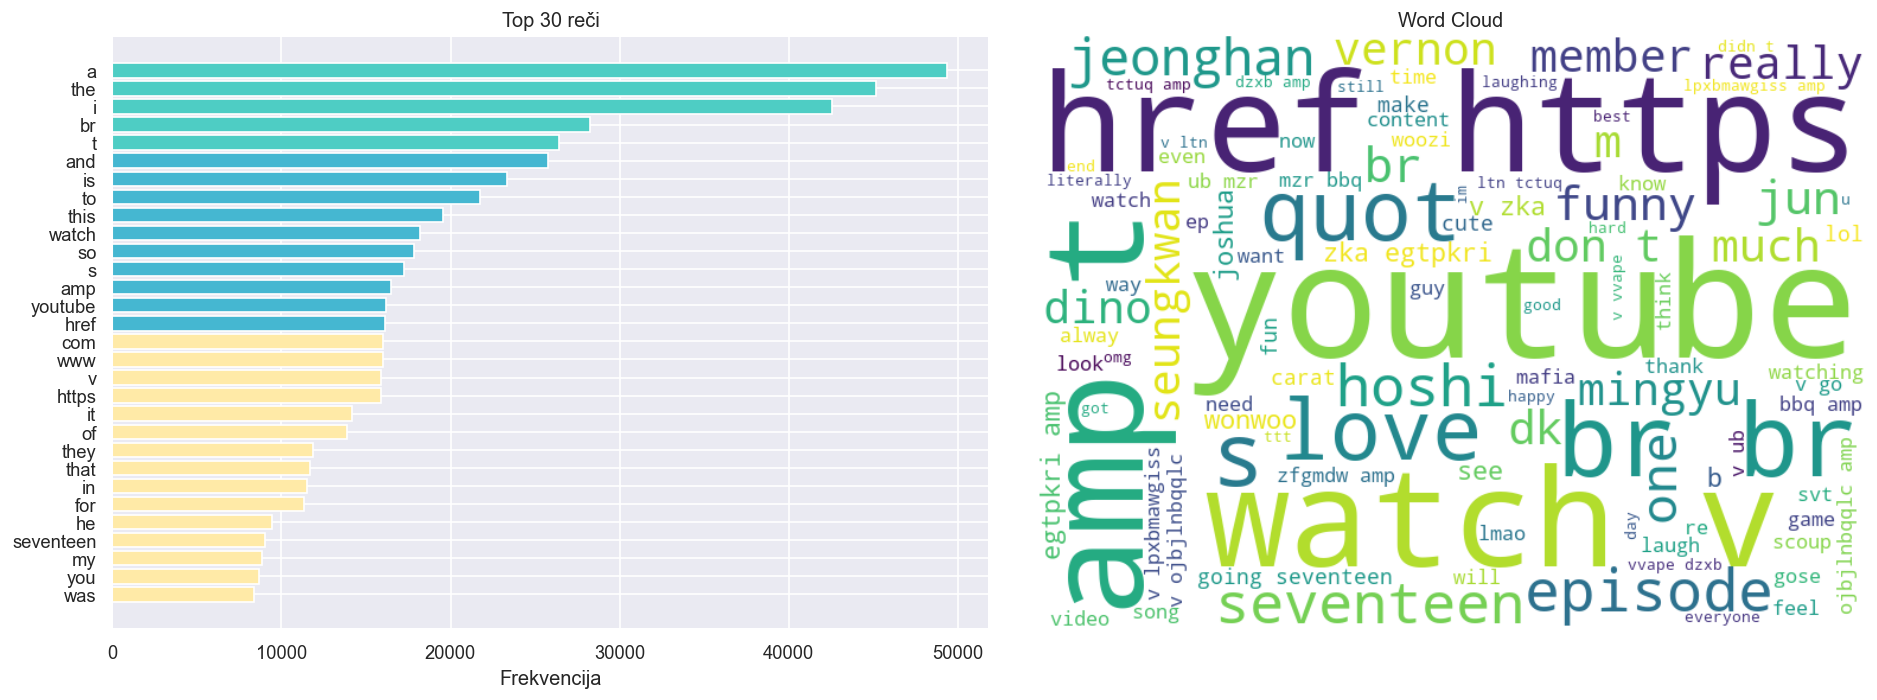

In [13]:
# filtered_words = [w for w in all_words_raw if w not in STOP_WORDS and len(w) > 2]
word_freq = Counter(all_words_raw)
top30 = word_freq.most_common(30)
words_top, counts_top = zip(*top30)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ['#4ECDC4' if i < 5 else '#45B7D1' if i < 15 else '#FFEAA7'
              for i in range(len(words_top))]
axes[0].barh(list(reversed(words_top)), list(reversed(counts_top)),
             color=list(reversed(colors_bar)), edgecolor='white')
axes[0].set_title('Top 30 reči')
axes[0].set_xlabel('Frekvencija')

wc = WordCloud(width=700, height=500, background_color='white',
               colormap='viridis', max_words=100).generate(' '.join(all_words_raw))
axes[1].imshow(wc, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud')

plt.tight_layout()
plt.show()

Najčešće reči u komentarima su *watch*, *youtube*, *seventeen*, *episode*, *love* i *like*, što ukazuje na spontano izražavanje emocija i fokus na samu emisiju. Pojava imena članova grupe (Hoshi, Jeonghan, Jun, Joshua, Seungkwan) potvrđuje da fanovi aktivno komentarišu pojedince. Word cloud vizualizacija dodatno naglašava centralne teme: naziv emisije, članove grupe i emotivne reakcije publike (*funny*, *love*). Ovi nalazi pokazuju da fan zajednica kombinuje tehničke reference na platformu (YouTube, gledanje epizoda) sa sadržajem emisije i izražavanjem podrške članovima.

## <font color="dodgerblue"><b> Filtriranje wish komentara </b> </font>

Pošto se radi o temama koje bi fanove zanimale u budućnosti, najpre mora da se izvrši filtriranje komentara po željama, korišćenjem određenih ključnih reči. Želimo da uhvatimo sve komentare u kojima fanovi iskazuju **želje, sugestije, nostalgiju, očekivanja ili preporuke** za buduće epizode.  

### <font color="steelblue"><b> Regex pattern </b> </font>

In [14]:
WISH_PATTERNS = [
    # Direktne zelje
    r'\bi want\b', r'\bi wish\b', r'\bi hope\b', r'\bi need\b',
    r'\bid love\b', r"\bi('d| would) love to\b",
    r'\bwould love to see\b', r'\bwould love (if|when|for)\b',
    r'\bwould (like|love|want)\b',
    r'\bi really want\b', r'\bso badly want\b',

    # Sugestije i preporuke
    r'\bthey should\b', r'\bthey need to\b', r'\bthey have to\b',
    r'\bshould (do|make|have|bring|create|give|try|add|include)\b',
    r'\bwhy (dont|don\'t|not) they\b',
    r'\bplease (bring|do|make|have|create|give|show|include|add|try|do more)\b',
    r'\bcan (they|svt|seventeen|gose) (do|make|have|please|try)\b',
    r'\bhow about (a|an|doing|making|having)\b',
    r'\bit would be (great|amazing|awesome|nice|cool|fun|perfect) (if|to|when)\b',
    r'\bi think they should\b', r'\bi suggest\b',
    r'\bmy (idea|suggestion|request)\b',

    # Nostalgija i povratak
    r'\bbring back\b', r'\bi miss\b', r'\bwe miss\b',
    r'\bwe need (more|another|a)\b', r'\bmore of\b',
    r'\bplease (more|again|another)\b',
    r'\bwant (more|another|a|them to)\b',
    r'\bmissing (the|this|that|those)\b',

    # Ocekivanja i zeljna buduca epizoda
    r"\bcan'?t wait (to see|for|until)\b",
    r'\blooking forward to\b', r'\bexcited (for|to see|about)\b',
    r'\bnext (episode|season|time) (should|needs|please|must|better)\b',
    r'\bhope (they|we|svt|seventeen|next|the next|this)\b',
    r'\bwish (they|we|svt|the next|next)\b',

    # Ideje za epizode
    r'\bidea for (a|an|the|next)\b', r'\bformat (idea|suggestion)\b',
    r'\btheme (idea|suggestion|for next)\b',
    r'\bwhat if (they|svt|gose)\b',
    r'\bit would be (better|perfect|great) if they\b',

    # Molbe i direktne poruke kreatorima
    r'\b(gose|going seventeen) (should|needs|please|must)\b',
    r'\bproducers?\b', r'\b(please|pls) (do|make|have|give us|show)\b',
    r'\bgive us (more|another|a)\b', r'\bwe (need|want|deserve)\b',
]

wish_regex = re.compile('|'.join(WISH_PATTERNS), re.IGNORECASE)
df['is_wish'] = df['text'].apply(lambda x: bool(wish_regex.search(str(x))))
df_wish = df[df['is_wish']].copy()

print(f'Ukupno komentara:    {len(df):,}')
print(f'Wish komentara:      {len(df_wish):,} ({len(df_wish)/len(df)*100:.1f}%)')
print()
print('Primeri wish komentara:')
for t in df_wish['text'].sample(5, random_state=42):
    clean = re.sub(r'<[^>]+>|&[a-z#0-9]+;', ' ', str(t))
    print(f'  > {re.sub(r"  +", " ", clean).strip()[:140]}')

Ukupno komentara:    74,552
Wish komentara:      4,638 (6.2%)

Primeri wish komentara:
  > For a group of 13, running together for 10 years, with this level of bonding, it really makes sense now. This is SEVENTEEN. This is why they
  > I’m so excited to see them scared ahhahahahaha
  > Honestly speaking, yes I love gose editors but they have to up their game!!! We all know the boys are naturally funny so personally I think 
  > This was so funny LMFAO. I think my favorite so far was Hoshi when he was supposed to be singing that really took me out 😭 then it would be 
  > I want more Best Friends episodes they are so much fun 😂😂😂


### <font color="steelblue"><b> Klasifikacija tipa želja </b> </font>

In [15]:
WISH_CATEGORIES = {
    'Games and activity': [
        'mafia', 'game', 'quiz', 'challenge', 'horror', 'cook', 'cooking',
        'sport', 'sports', 'compete', 'competition', 'hide', 'seek',
        'escape', 'haunted', 'ghost', 'scary', 'mission', 'race',
        'scavenger', 'camping', 'survival', 'dance battle', 'arcade'
    ],
    'Talk show': [
        'podcast', 'talk', 'interview', 'reaction', 'vlog', 'behind',
        'documentary', 'reality', 'variety', 'mukbang', 'asmr',
        'q&a', 'q a', 'question', 'answer', 'live', 'commentary',
        'unboxing', 'tutorial', 'review'
    ],
    'Group dynamic': [
        'unit', 'ot13', 'collab', 'pair', 'subunit', 'solo',
        'all thirteen', 'all 13', 'full group', 'together', 'duo',
        'trio', 'vocal unit', 'performance unit', 'hip hop unit'
    ],
    'Emotions': [
        'funny', 'laugh', 'fun', 'emotional', 'sweet', 'wholesome',
        'heartwarming', 'relax', 'relaxed', 'calm', 'intense',
        'wild', 'chaos', 'chaotic', 'chill', 'soft', 'cute'
    ],
    'Travelling': [
        'travel', 'trip', 'outdoor', 'country', 'city', 'abroad',
        'tour', 'vacation', 'road', 'nature', 'beach', 'mountain',
        'international', 'japan', 'usa', 'europe', 'korea'
    ],
    'Music and performance': [
        'performance', 'dance', 'singing', 'music', 'cover',
        'choreography', 'song', 'concert', 'stage', 'practice',
        'studio', 'record', 'acoustic', 'rap', 'vocal'
    ],
    'Repeated format': [
        'bring back', 'miss', 'again', 'return', 'more of',
        'remember when', 'used to', 'old', 'classic', 'original',
        'first', 'throwback', 'nostalgia', 'like before', 'the way they'
    ],
}

def classify_wish(text):
    text_l = str(text).lower()
    scores = {}
    for cat, keywords in WISH_CATEGORIES.items():
        score = sum(1 for kw in keywords if kw in text_l)
        if score > 0:
            scores[cat] = score
    if not scores:
        return 'Other'
    return max(scores, key=scores.get)

df_wish['wish_category'] = df_wish['text'].apply(classify_wish)

print('Distribucija tipova želja:')
cat_counts = df_wish['wish_category'].value_counts()
for cat, cnt in cat_counts.items():
    bar = '█' * int(cnt / cat_counts.max() * 30)
    print(f'  {cat:<25} {cnt:>5}  {bar}')

Distribucija tipova želja:
  Other                      1885  ██████████████████████████████
  Emotions                    726  ███████████
  Repeated format             636  ██████████
  Talk show                   485  ███████
  Games and activity          404  ██████
  Music and performance       309  ████
  Group dynamic               137  ██
  Travelling                   56  


In [19]:
df_other = df_wish[df_wish['wish_category'] == 'Other'].copy()

print(f'Ukupno OTHER komentara: {len(df_other)}')
print('\nPrimeri:\n')

for t in df_other['text'].sample(10, random_state=42):
    print('-', t[:150])

Ukupno OTHER komentara: 1885

Primeri:

- <a href="https://www.youtube.com/watch?v=QUrgUJViAZU&amp;t=1268">21:08</a> please give subtitle with English
- please we need a season 2 of this HAHAHAHHAHA
- I want translate malay😭
- Im looking forward to what Shua will do. I know he will have his revenge😆
- please i just want a friend group like seventeen!!
- Pledis we want more TTT episodes
- <a href="https://www.youtube.com/watch?v=M75NAPmAd9g&amp;t=981">16:21</a> DK giving encouragement to green and getting stressed a second after <a href
- Poor Seungkwan. I want to pat his head :D
- I want this kind of episode.  They give us more knowledge about them, on how they enjoyed their free time, on how they&#39;d taking care off of the me
- okay i need to stan this guys now ahaha


In [22]:
def tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

all_words = []
for t in df_other['text']:
    all_words.extend(tokenize(t))

word_counts = Counter(all_words)

print('\nNajčešće reči u OTHER:\n')
for word, cnt in word_counts.most_common(30):
    print(f'{word:<15} {cnt}')


Najčešće reči u OTHER:

i               1990
to              1074
the             922
a               814
br              700
this            603
and             602
for             548
want            523
need            509
they            379
so              379
of              366
seventeen       346
t               346
we              344
is              340
s               334
it              320
you             296
in              263
that            258
hope            257
like            250
m               244
be              242
please          223
episode         214
more            211
my              208


In [28]:
def preprocess(text):
    text = str(text).lower()

    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)

    text = re.sub(r'[^a-z\s]', ' ', text)

    tokens = text.split()

    tokens = [w for w in tokens if w not in STOP_WISH and len(w) > 2]

    return tokens

STOP_WISH = set(stopwords.words('english')) | {
    # Opste reci bez semantike u ovom kontekstu
    'like', 'think', 'really', 'also', 'see', 'know', 'come',
    'show', 'feel', 'miss', 'episode', 'season', 'content', 'video',
    'watch', 'watching', 'next', 'back', 'more', 'go', 'one', 'time',
    'still', 'even', 'ever', 'always', 'already', 'never', 'much', 'many',
    # Trigger reci za wish (same po sebi nisu informativne)
    'want', 'wish', 'hope', 'need', 'please', 'bring', 'make', 'would',
    'could', 'should', 'will', 'maybe', 'love', 'really', 'definitely',
    # Nazivi grupe i emisije
    'gose', 'seventeen', 'svt', 'going', 'member',
    # HTML artefakti
    'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'www',
}

df_other['tokens'] = df_other['text'].apply(preprocess)

In [29]:
from collections import Counter

all_words = []
for tokens in df_other['tokens']:
    all_words.extend(tokens)

word_counts = Counter(all_words)

print('\nNajčešće reči u OTHER (clean):\n')
for word, cnt in word_counts.most_common(30):
    print(f'{word:<15} {cnt}')


Najčešće reči u OTHER (clean):

excited         154
wait            142
hoshi           113
cant            111
carats          94
jeonghan        86
ttt             86
jun             82
year            76
give            75
get             75
members         74
part            68
wonwoo          64
str             64
right           63
good            63
happy           62
woozi           61
guys            60
lol             60
best            58
week            57
looking         56
new             54
forward         53
seungkwan       50
mingyu          48
friends         48
day             47


Početna analiza kategorije **Other** pokazala je visok nivo šuma usled prisustva HTML oznaka i čestih funkcijskih reči. Nakon dodatne obrade teksta (uklanjanje stop reči i šuma), identifikovani su novi obrasci ali ponovo ne sa nekim karakterističnim rečima koje bi se mogle staviti u posebne sekcije.

### <font color="steelblue"><b> Distribucija i statistika wish komentara </b> </font>

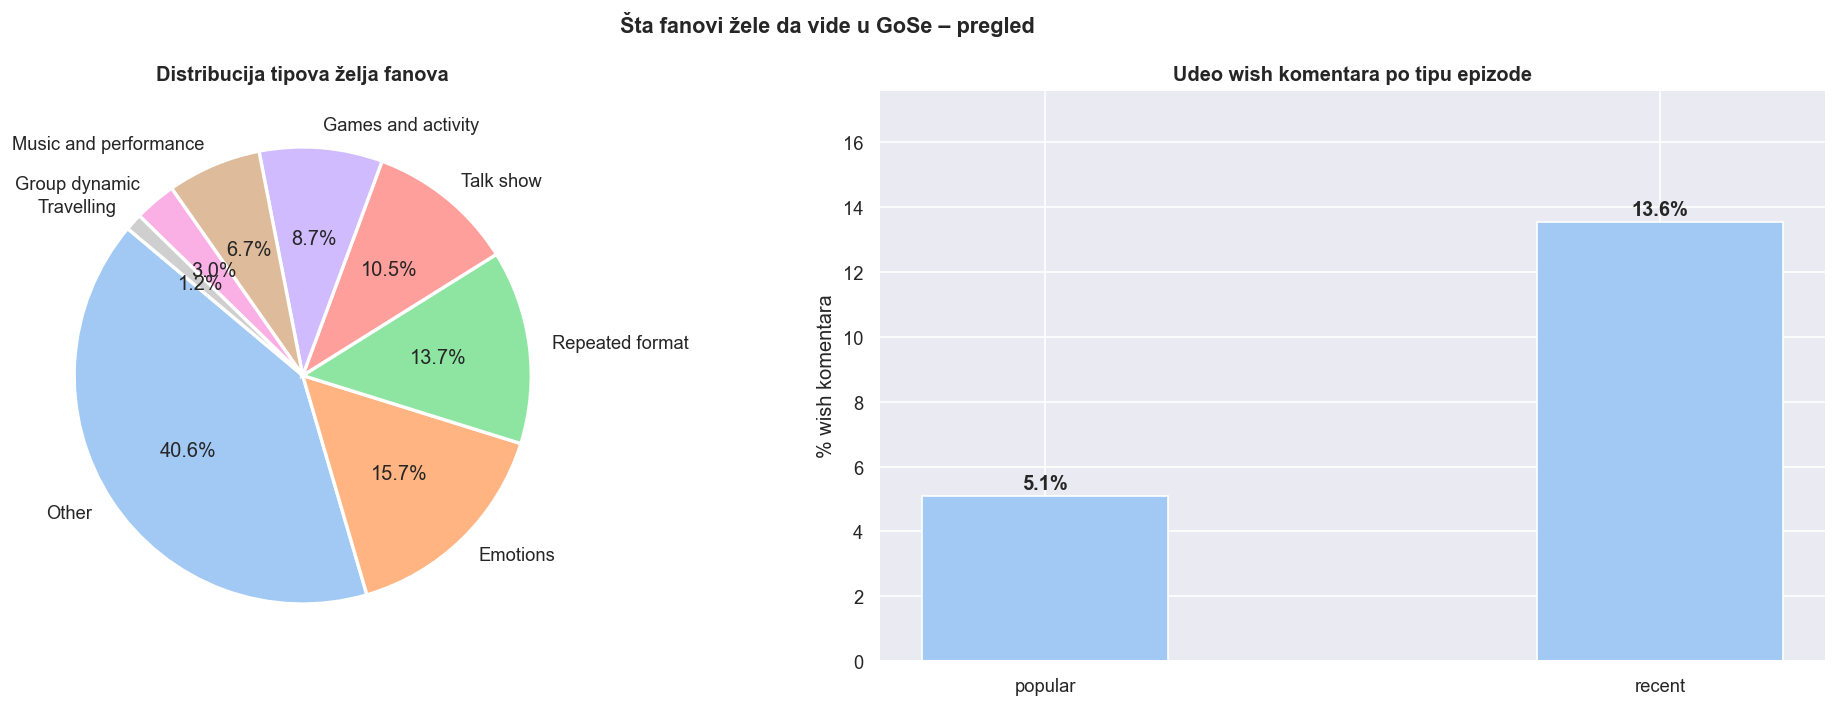


=== LIKES: Wish vs. Non-wish komentari ===
  Prosečni likes – wish:     49.87
  Prosečni likes – non-wish: 54.84
  -> Wish komentari su manje lajkovani


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

cat_counts = df_wish['wish_category'].value_counts()
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
axes[0].pie(cat_counts.values, labels=cat_counts.index, autopct='%1.1f%%',
            wedgeprops=wedge_props, startangle=140)
axes[0].set_title('Distribucija tipova želja fanova', fontweight='bold')

wish_by_type = df.groupby('type')['is_wish'].agg(['sum', 'count'])
wish_by_type['pct'] = wish_by_type['sum'] / wish_by_type['count'] * 100

axes[1].bar(wish_by_type.index, wish_by_type['pct'], edgecolor='white', width=0.4)
for i, (idx, row) in enumerate(wish_by_type.iterrows()):
    axes[1].text(i, row['pct'] + 0.2, f"{row['pct']:.1f}%", ha='center', fontweight='bold')
axes[1].set_title('Udeo wish komentara po tipu epizode', fontweight='bold')
axes[1].set_ylabel('% wish komentara')
axes[1].set_ylim(0, wish_by_type['pct'].max() * 1.3)

plt.suptitle('Šta fanovi žele da vide u GoSe – pregled', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== LIKES: Wish vs. Non-wish komentari ===')
print(f"  Prosečni likes – wish:     {df_wish['likes'].mean():.2f}")
print(f"  Prosečni likes – non-wish: {df[~df['is_wish']]['likes'].mean():.2f}")
print(f"  -> Wish komentari su {'vise' if df_wish['likes'].mean() > df[~df['is_wish']]['likes'].mean() else 'manje'} lajkovani")

## <font color="dodgerblue"><b> Predobrada teksta </b> </font>

### <font color="steelblue"><b> Normalizacija </b> </font>

In [31]:
def normalize(text):
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)          # HTML tagovi (<a href=...>, <br>, itd.)
    text = re.sub(r'&[a-z#0-9]+;', ' ', text)     # HTML entiteti (&amp; &quot; &#39;)
    text = re.sub(r'http\S+|www\.\S+', '', text)  # URL-ovi
    text = re.sub(r'@\w+', '', text)               # @mentions
    text = re.sub(r'[^a-z\s]', '', text)           # interpunkcija i brojevi
    text = re.sub(r'\s+', ' ', text).strip()
    return text

### <font color="steelblue"><b> Tokenizacija </b> </font>

In [32]:
def tokenize(text):
    return word_tokenize(normalize(text))

### <font color="steelblue"><b> Uklanjanje stop reči </b> </font>

In [33]:
STOP_WISH = set(stopwords.words('english')) | {
    'im', 'ive', 'dont', 'cant', 'wont', 'didnt', 'isnt', 'wasnt',
    'youre', 'theyre', 'theyve', 'wouldnt', 'shouldnt', 'couldnt',
    'na', 'gonna', 'gotta', 'kinda', 'wanna',
    'yeah', 'yea', 'nah', 'ok', 'okay', 'ngl',
    'like', 'think', 'really', 'also', 'see', 'know', 'come',
    'show', 'feel', 'miss', 'episode', 'season', 'content', 'video',
    'watch', 'watching', 'next', 'back', 'more', 'go', 'one', 'time',
    'still', 'even', 'ever', 'always', 'already', 'never', 'much', 'many',
    'want', 'wish', 'hope', 'need', 'please', 'bring', 'make', 'would',
    'could', 'should', 'will', 'maybe', 'love', 'definitely',
    'gose', 'seventeen', 'svt', 'going', 'member',
    'href', 'bra', 'amp', 'quot', 'br', 'lt', 'gt', 'http', 'https', 'www',
}

def remove_stopwords(tokens):
    return [t for t in tokens if t not in STOP_WISH and len(t) > 2]

### <font color="steelblue"><b> Lematizacija </b> </font>

In [34]:
lemm = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemm.lemmatize(t) for t in tokens]

In [37]:
df_wish['text_norm'] = df_wish['text'].apply(normalize)

df_wish['tokens'] = df_wish['text_norm'].apply(tokenize)

df_wish['tokens_nostop'] = df_wish['tokens'].apply(remove_stopwords)

df_wish['tokens_lemma'] = df_wish['tokens_nostop'].apply(lemmatize_tokens)

df_wish['text_clean'] = df_wish['tokens_lemma'].apply(lambda x: ' '.join(x))
df_wish['text_nostop'] = df_wish['tokens_nostop'].apply(lambda x: ' '.join(x))

In [36]:
all_words = [w for tokens in df_wish['tokens_lemma'] for w in tokens]

word_counts = Counter(all_words)

top_30 = word_counts.most_common(30)

print('Top 30 najčešćih reči (lemma):\n')
for word, count in top_30:
    bar = '█' * (count // max(1, top_30[0][1] // 30))
    print(f'{word:<20} {count:>5}  {bar}')

Top 30 najčešćih reči (lemma):

fun                    579  ██████████████████████████████
member                 537  ████████████████████████████
carat                  533  ████████████████████████████
get                    349  ██████████████████
game                   344  ██████████████████
jun                    333  █████████████████
hoshi                  322  ████████████████
episode                288  ███████████████
wonwoo                 287  ███████████████
jeonghan               280  ██████████████
wait                   278  ██████████████
year                   268  ██████████████
hard                   262  █████████████
team                   252  █████████████
good                   251  █████████████
happy                  251  █████████████
thank                  247  █████████████
funny                  242  ████████████
guy                    236  ████████████
excited                235  ████████████
give                   233  ████████████
thing              

## <font color="dodgerblue"><b> Popularnost clanova grupe – rangiranje po pominjanju </b> </font>

## <font color="dodgerblue"><b> BERTopic – Varijanta A: Sentence Transformers + c-TF-IDF </b> </font>

## <font color="dodgerblue"><b> BERTopic – Varijanta B: Word2Vec doc embeddings </b> </font>

## <font color="dodgerblue"><b> LDA - Baseline </b> </font>

## <font color="dodgerblue"><b> NMF - Baseline </b> </font>

## <font color="dodgerblue"><b> Analiza tema po popularnim vs. nedavnim epizodama </b> </font>

## <font color="dodgerblue"><b> Analiza Wish komentara – Sta fanovi zele da gledaju? </b> </font>

## <font color="dodgerblue"><b> Vizuelizacije </b> </font>

### <font color="steelblue"><b> BERTopic – interaktivne vizualizacije (c-TF-IDF) </b> </font>

### <font color="steelblue"><b> Word Clouds – BERTopic c-TF-IDF </b> </font>

### <font color="steelblue"><b> Heatmapa tema po videu </b> </font>

## <font color="dodgerblue"><b> Evaluacija i poredenje modela </b> </font>

## <font color="dodgerblue"><b> Rezime </b> </font>